# Титаник 


# Тестовое задание (ML)

Необходимо на датасете «Титаник» обучить модель, предсказывающую выживших
(`survived`), и в качестве ответа сообщить accuracy на тесте.

## Данные


```python
from sklearn.datasets import fetch_openml
df = fetch_openml("titanic", version=1, as_frame=True).frame
```

## Вводные

- сделайте train/test split 80/20 (`random_state=42`);
- закодируйте категориальные признаки (способ на ваше усмотрение);
- заполните пропуски (способ на ваше усмотрение);
- обучите случайный лес (`RandomForestClassifier`, параметры на ваше усмотрение).

## Как сдавать

- Пришлите Python-скрипт
  (`task2_solution.py`) с полным кодом: загрузка данных → препроцессинг →
  обучение → оценка.
- В этом скрипте первой строчкой должен быть комментарий со значением Accuracy на тесте (например, # Accuracy on test: 0.0000)
- Сам код в ход выполнения должен печатать итоговый ответ той же строкой:
  `Accuracy on test: <значение>` (4 знака после запятой).
- Код должен воспроизводимо запускаться сверху вниз и выдавать тот же ответ.


In [39]:
# Библиотеки
import numpy as np
import pandas as pd

# Данные и train/test
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Препроцессинг
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Модель и метрика
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [40]:
df = fetch_openml("titanic", version=1, as_frame=True).frame

In [41]:
display(df.head())

print(df.shape)

display(df.info())

display(df.describe())

display(df.describe(include="object"))


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


(1309, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 176.1 KB


None

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


/tmp/ipykernel_5521/2649416280.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,name,ticket,cabin,boat,home.dest
count,1309,1309,295,486,745
unique,1307,929,186,27,369
top,"Connolly, Miss. Kate",CA. 2343,C23 C25 C27,13,"New York, NY"
freq,2,11,6,39,64


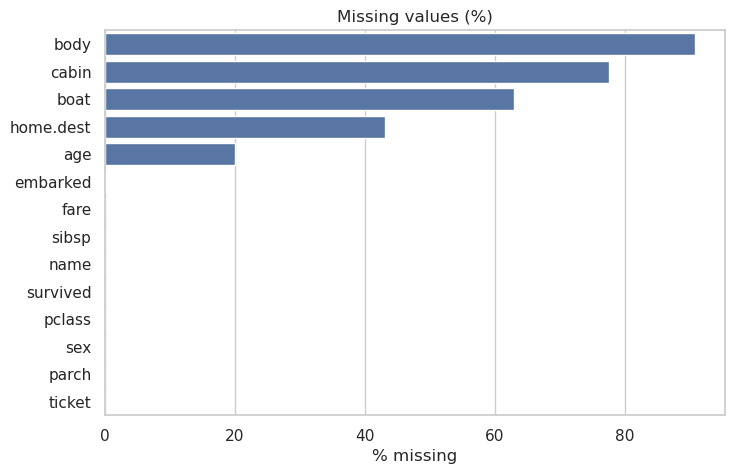

In [42]:
# MISSING VALUES
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .mul(100)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.xlabel("% missing")
plt.ylabel("")
plt.title("Missing values (%)")

plt.show()


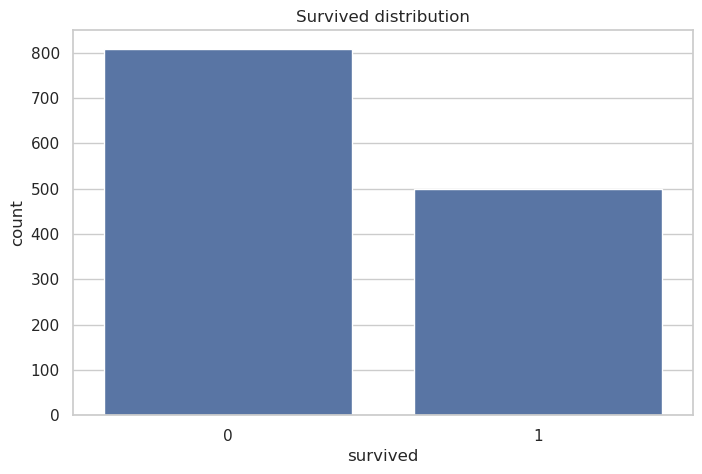

In [43]:
# TARGET
sns.countplot(
    data=df,
    x="survived"
)

plt.title("Survived distribution")
plt.show()

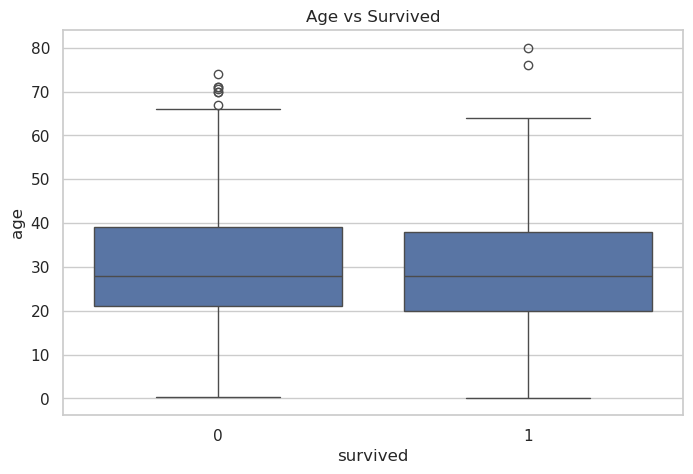

In [44]:
sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age vs Survived")
plt.show()

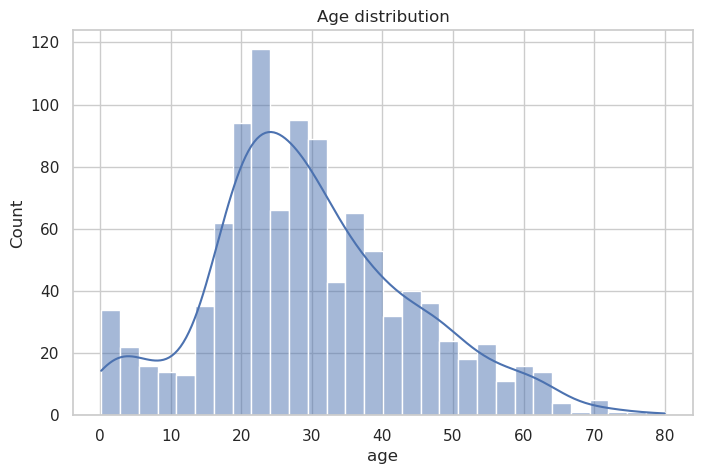

In [45]:
# AGE
sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age distribution")
plt.show()

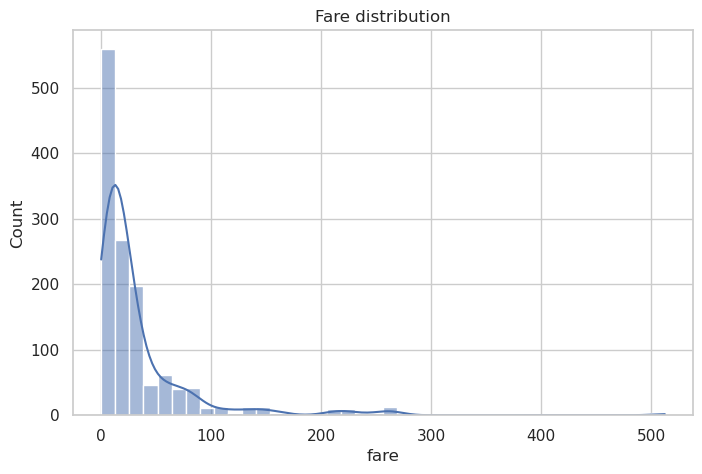

In [46]:
# FARE
sns.histplot(
    data=df,
    x="fare",
    bins=40,
    kde=True
)

plt.title("Fare distribution")
plt.show()

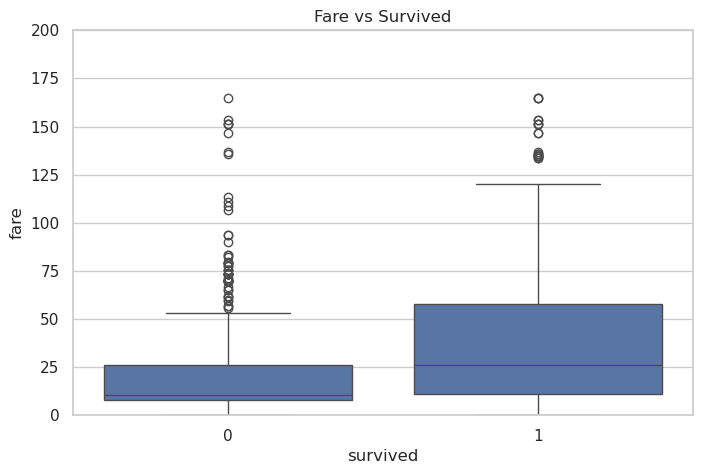

In [47]:
sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare vs Survived")
plt.ylim(0, 200)

plt.show()

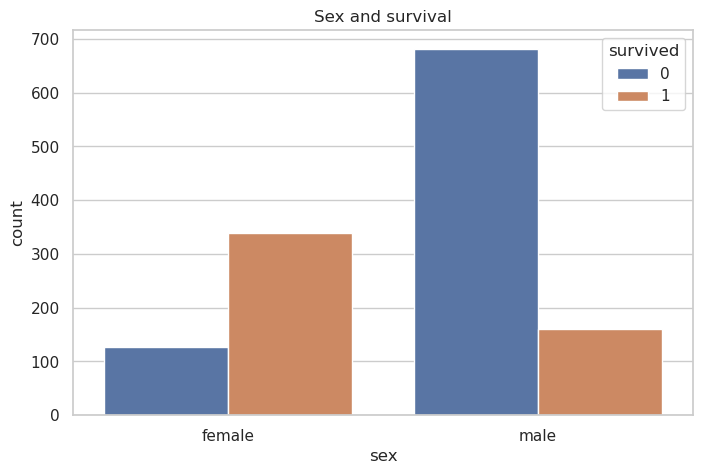

In [48]:
# SEX
sns.countplot(
    data=df,
    x="sex",
    hue="survived"
)

plt.title("Sex and survival")
plt.show()

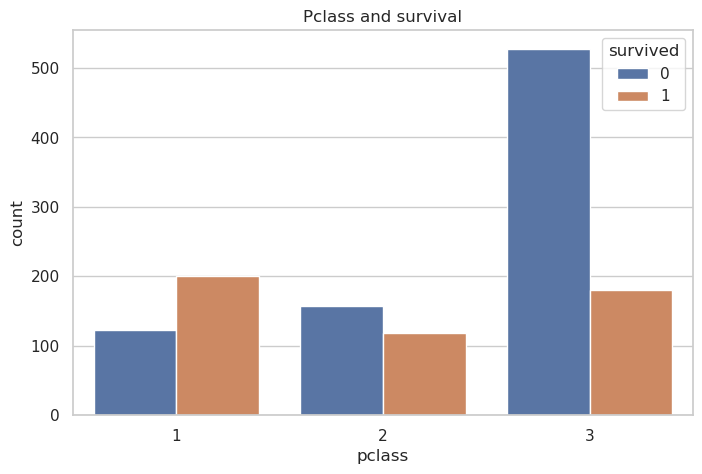

In [49]:
#PCLASS
sns.countplot(
    data=df,
    x="pclass",
    hue="survived"
)

plt.title("Pclass and survival")
plt.show()

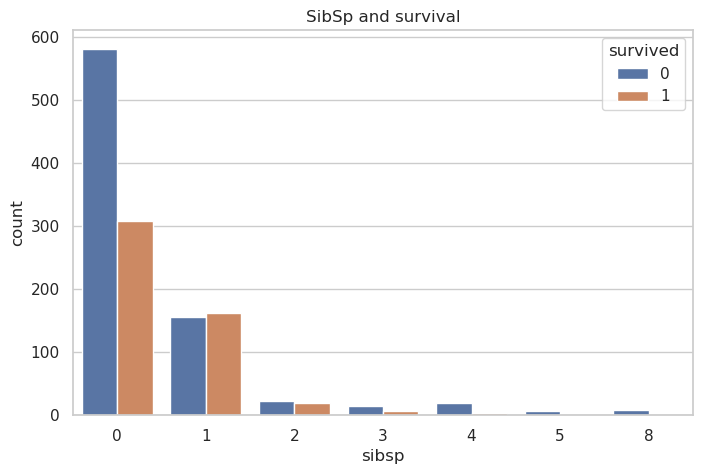

In [50]:
# SIBSP
sns.countplot(
    data=df,
    x="sibsp",
    hue="survived"
)

plt.title("SibSp and survival")
plt.show()

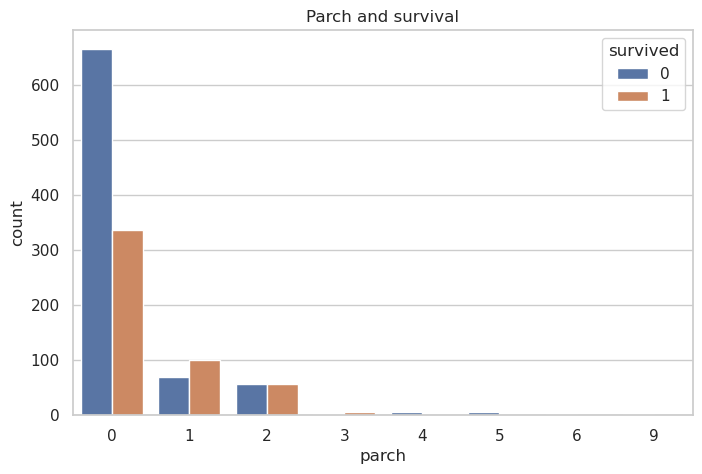

In [51]:
# PARCH
sns.countplot(
    data=df,
    x="parch",
    hue="survived"
)

plt.title("Parch and survival")
plt.show()

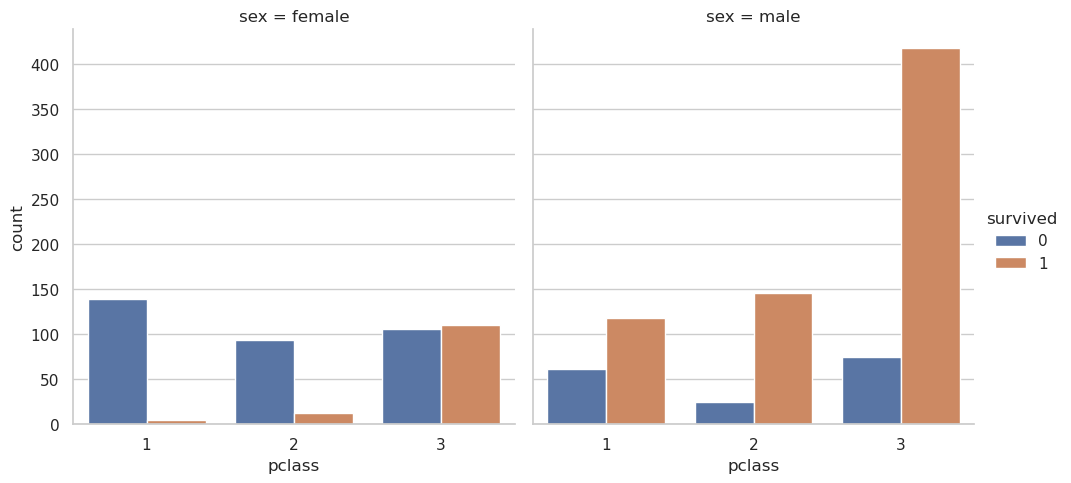

In [52]:
# SEX + PCLASS
sns.catplot(
    data=df,
    x="pclass",
    hue="survived",
    col="sex",
    kind="count"
)

<Axes: xlabel='sex', ylabel='age'>

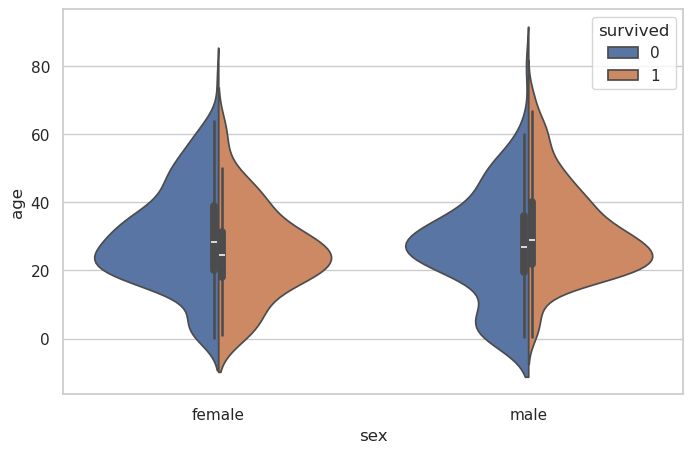

In [53]:
# AGE + SEX
sns.violinplot(
    data=df,
    x="sex",
    y="age",
    hue="survived",
    split=True
)

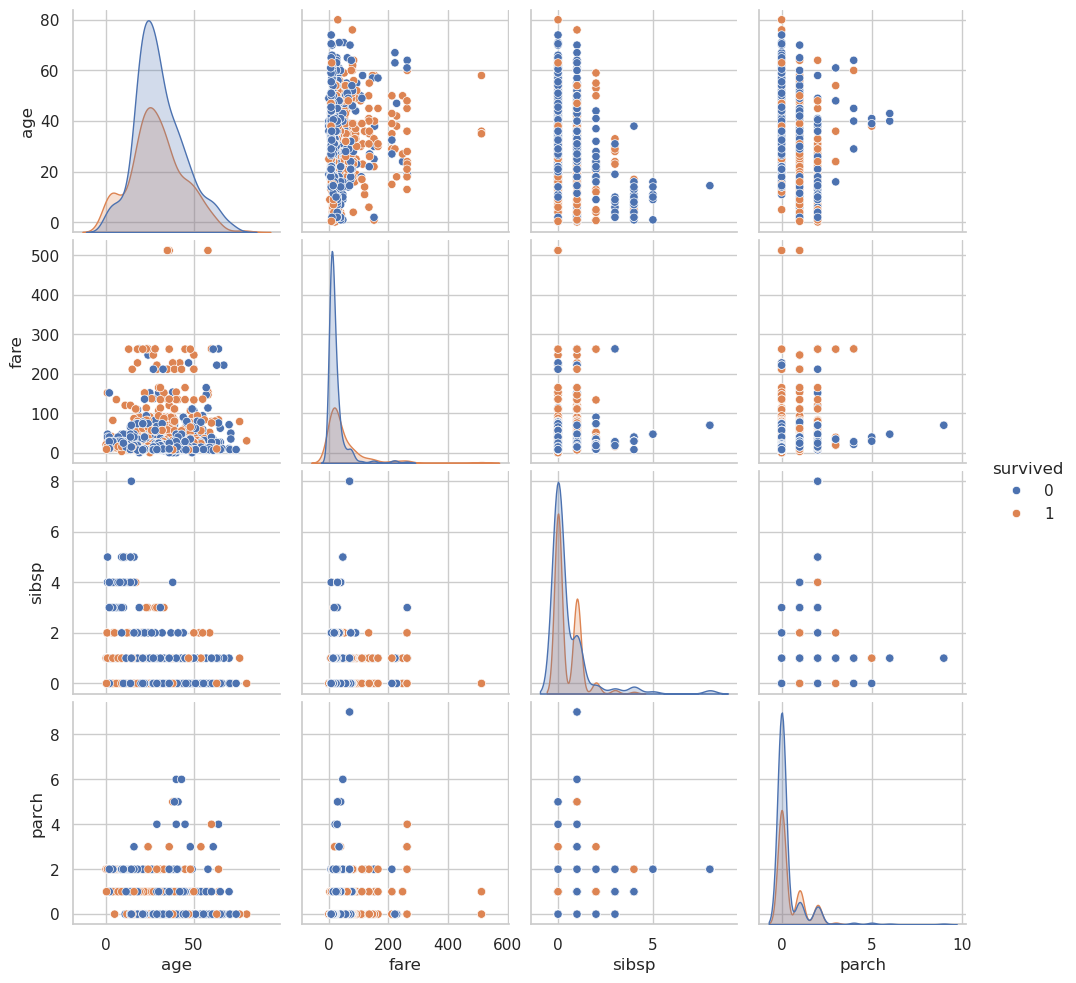

In [54]:
# Pairplot 
cols = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "survived"
]

sns.pairplot(
    df[cols],
    hue="survived"
)

## 7. Базовые графики / Core graphs

## Итоги EDA 
